<a href="https://colab.research.google.com/github/KarolOszek/lol-match-predictor/blob/main/testing%20pytorch%20model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import shap
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, roc_auc_score, log_loss

In [11]:
df_all = pd.read_csv('teams_data.csv')

In [12]:
def get_match_history(df, team_a, team_b, N=20):
  team_a_matches = df[df['Team'] == team_a].tail(N)
  team_b_matches = df[df['Team'] == team_b].tail(N)
  stats_cols = ['Kills', 'Gold/sec', 'Towers', 'Dragons',
                  'Kills/15 minute', 'Gold/sec/15 minute',
                  'Towers/15 minute', 'Dragons/15 minute']
  team_a_stats = team_a_matches[stats_cols].mean()
  team_b_stats = team_b_matches[stats_cols].mean()

  diff_features = team_a_stats - team_b_stats

  diff_features.index = [f'{col}_diff' for col in diff_features.index]

  return diff_features

In [13]:
X_list = []
y_list = []
for idx, row in df_all.iterrows():
    team_a = row['Team']
    team_b = row['Vs']

    features = get_match_history(df_all, team_a=team_a, team_b=team_b, N=20)
    features.name = f"{team_a}_vs_{team_b}_{idx}"

    if features is not None and not features.isna().any():
        X_list.append(features)
        y_list.append(row['Result'])

X = pd.DataFrame(X_list)
y = pd.Series(y_list, name='Result')
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [14]:
class MatchPredictingModel(nn.Module):
  def __init__(self, feature_amount):
    super().__init__()
    self.layer1 = nn.Linear(feature_amount, 64)
    self.activation1 = nn.ELU()
    self.dropout1 = nn.Dropout(0.3)

    self.layer2 = nn.Linear(64, 32)
    self.activation2 = nn.ELU()
    self.dropout2 = nn.Dropout(0.3)

    self.layer3 = nn.Linear(32, 16)
    self.activation3 = nn.ELU()
    self.dropout3 = nn.Dropout(0.3)

    self.layer4 = nn.Linear(16, 1)
    self.activation4 = nn.Sigmoid()

  def forward(self, x):
    x = self.layer1(x)
    x = self.activation1(x)
    x = self.dropout1(x)

    x = self.layer2(x)
    x = self.activation2(x)
    x = self.dropout2(x)

    x = self.layer3(x)
    x = self.activation3(x)
    x = self.dropout3(x)

    x = self.layer4(x)
    x = self.activation4(x)
    return x


In [15]:
model = MatchPredictingModel(feature_amount=X_train_scaled.shape[1])
optimizer = optim.Adam(model.parameters(), lr=0.002)
criterion = nn.BCELoss()

In [16]:
X_train_scaled_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)

model.train()
for epoch in range(400):
  optimizer.zero_grad()
  prediction = model(X_train_scaled_tensor)
  loss = criterion(prediction, y_train_tensor)
  loss.backward()
  optimizer.step()
  if (epoch + 1) % 10 == 0:
        print(f'Epoch: {epoch+1}/100 | Loss: {loss.item():.4f}')

Epoch: 10/100 | Loss: 0.5084
Epoch: 20/100 | Loss: 0.4816
Epoch: 30/100 | Loss: 0.4712
Epoch: 40/100 | Loss: 0.4749
Epoch: 50/100 | Loss: 0.4716
Epoch: 60/100 | Loss: 0.4777
Epoch: 70/100 | Loss: 0.4643
Epoch: 80/100 | Loss: 0.4412
Epoch: 90/100 | Loss: 0.4325
Epoch: 100/100 | Loss: 0.4770
Epoch: 110/100 | Loss: 0.4662
Epoch: 120/100 | Loss: 0.4518
Epoch: 130/100 | Loss: 0.4438
Epoch: 140/100 | Loss: 0.4427
Epoch: 150/100 | Loss: 0.4558
Epoch: 160/100 | Loss: 0.4613
Epoch: 170/100 | Loss: 0.4460
Epoch: 180/100 | Loss: 0.4405
Epoch: 190/100 | Loss: 0.4453
Epoch: 200/100 | Loss: 0.4607
Epoch: 210/100 | Loss: 0.4379
Epoch: 220/100 | Loss: 0.4609
Epoch: 230/100 | Loss: 0.4600
Epoch: 240/100 | Loss: 0.4588
Epoch: 250/100 | Loss: 0.4690
Epoch: 260/100 | Loss: 0.4512
Epoch: 270/100 | Loss: 0.4550
Epoch: 280/100 | Loss: 0.4348
Epoch: 290/100 | Loss: 0.4561
Epoch: 300/100 | Loss: 0.4448
Epoch: 310/100 | Loss: 0.4769
Epoch: 320/100 | Loss: 0.4347
Epoch: 330/100 | Loss: 0.4653
Epoch: 340/100 | Lo

In [17]:
model.eval()
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)
with torch.no_grad():
  test_predictions = model(X_test_tensor)
  predicted_classes = (test_predictions >= 0.5).float()

  correct_predictions = (predicted_classes == y_test_tensor).sum().item()
  accuracy = correct_predictions / len(y_test_tensor)
  print(f'Accuracy on test samples: {accuracy * 100:.2f}%')

Accuracy on test samples: 78.57%


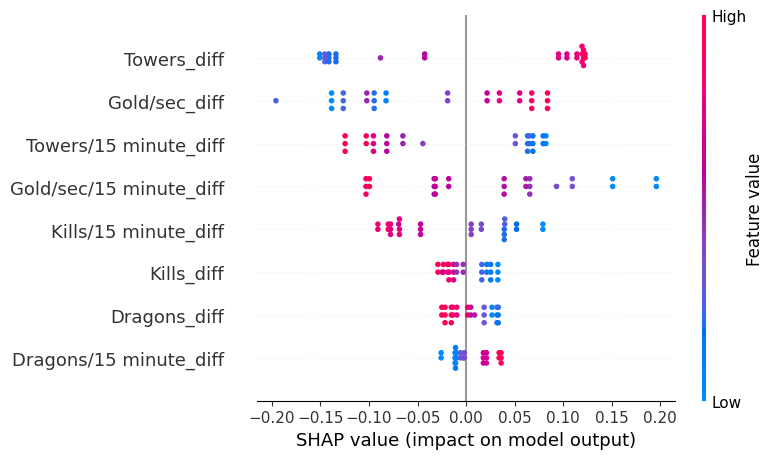

In [19]:
background = X_train_scaled_tensor[:100]
explainer = shap.DeepExplainer(model, background)
shap_values = explainer.shap_values(X_test_tensor)

if isinstance(shap_values, list):
    sv_fixed = shap_values[0]
else:
    sv_fixed = shap_values

sv_fixed = np.array(sv_fixed).reshape(X_test_scaled.shape)
shap.summary_plot(sv_fixed, X_test_scaled, feature_names=X_train.columns)